In [2]:
import math
import os
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import torch
# from lib.AnalyzeLib import *
from lib.SymapsModel import *
from torchvision import models
from torchsummary import summary
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, Subset

In [3]:
%load_ext autoreload
%autoreload 2

# Test code

In [6]:
t = torch.ones((4,3,5))
conv = torch.nn.Conv1d(3,2,2,stride=2,padding=1,padding_mode= 'replicate')
t.permute((0,2,1))
t = conv(t)
# t, (t - torch.mean(t,dim=1,keepdim=True))/torch.std(t,dim=1,keepdim=True), nn.functional.normalize(t,dim=1)
t.shape,torch.std(t,dim=(0,1),keepdim=False).shape

(torch.Size([4, 2, 3]), torch.Size([3]))

In [7]:
a = torch.tensor(
    [[ 0.2035,  1.2959,  1.8101, -0.4644],
     [ 1.5027, -0.3270,  0.5905,  0.6538],
     [-1.5745,  1.3330, -0.5596, -0.6548],
     [ 0.1264, -0.5080,  1.6420,  0.1992]]
)  # fmt: skip
torch.max(a, dim=0, keepdim=True).values

tensor([[1.5027, 1.3330, 1.8101, 0.6538]])

# Traning

## test AE model

In [8]:
model = ConvAEModel()
print(model)

ConvAEModel(
  (encoder): Sequential(
    (0): Conv1d(4, 64, kernel_size=(10,), stride=(1,))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.2, inplace=False)
    (3): Conv1d(64, 32, kernel_size=(10,), stride=(1,))
    (4): LeakyReLU(negative_slope=0.01)
    (5): Dropout(p=0.2, inplace=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(32, 64, kernel_size=(10,), stride=(1,))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.2, inplace=False)
    (3): ConvTranspose1d(64, 4, kernel_size=(10,), stride=(1,))
  )
)


In [9]:
df = pd.read_csv('./dataset10/training/training_20252810_18:32:01.csv')
df_1 = df.loc[:,['rot_x','rot_y','VelX','VelY']].copy()
# df_1 = (df_1 - df_1.mean())/df_1.std()
df_1.head(2),df_1[df_1.isnull().any(axis=1)]

(       rot_x      rot_y      VelX      VelY
 0 -36.585278  21.052720  0.635239 -2.212799
 1 -36.607939  21.120844  0.552521 -1.921320,
 Empty DataFrame
 Columns: [rot_x, rot_y, VelX, VelY]
 Index: [])

In [10]:
df.head(2)

,Id,timestamp,positionX,positionY,positionZ,sizeX,sizeY,sizeZ,VelX,VelY,VelZ,Vel,Class,rot_x,rot_y,edge,ts,departure,destination
0,497.0,1.607508e+12,18.558039,37.911724,-5.208592,2.280339,0.906446,0.614373,0.635239,-2.212799,-0.029671,8.288517,UNKNOWN,-36.585278,21.052720,60546306#1,0.0,60546306#1,60546290#0
1,497.0,1.607508e+12,18.538731,37.980873,-5.116337,2.211268,0.892957,0.585550,0.552521,-1.921320,0.136884,7.213925,UNKNOWN,-36.607939,21.120844,60546306#1,1.0,60546306#1,60546290#0


In [11]:
# classification of trajectories
df_1 = df.groupby(by=['departure','destination']).get_group(('60546306#1','60546290#0')).loc[:,['rot_x','rot_y','VelX','VelY']].copy()
df_1.head(2),df_1[df_1.isnull().any(axis=1)]

(       rot_x      rot_y      VelX      VelY
 0 -36.585278  21.052720  0.635239 -2.212799
 1 -36.607939  21.120844  0.552521 -1.921320,
 Empty DataFrame
 Columns: [rot_x, rot_y, VelX, VelY]
 Index: [])

In [41]:
sq, _ = df_1.shape
batch = int(sq/50)
batch, sq

(1885, 94250)

In [355]:
df_ts = torch.tensor(df_1.values)
df_ts = df_ts.view(batch,50,4)
# df_min = df_ts.min(dim=1,keepdim=True).values
# df_max = df_ts.max(dim=1,keepdim=True).values
# df_ts = 2*(df_ts - df_min)/(df_max - df_min)-1
# df_ts

In [356]:
split_rate = 0.8

train_batch_size = 20
train_params = {'batch_size': train_batch_size}

test_batch_size = 1
test_params = {'batch_size': test_batch_size}

train_df = df_ts[:int(batch*split_rate)].detach().clone()
test_df = df_ts[int(batch*split_rate):].detach().clone()

# train_mean = torch.mean(df_ts,dim=1,keepdim=True)
# train_std = torch.std(df_ts,dim=1,keepdim=True)
train_mean = torch.mean(train_df,dim=(0,1),keepdim=True)
train_std = torch.std(train_df,dim=(0,1),keepdim=True)

test_df = (test_df - train_mean)/train_std
# test_df = (test_df - test_df.mean(dim=1,keepdim=True))/test_df.std(dim=1,keepdim=True)
# test_df = (test_df - df_ts.min(dim=0,keepdim=True).values.min(dim=1).values)/(df_ts.max(dim=0,keepdim=True).values.max(dim=1).values - df_ts.min(dim=0,keepdim=True).values.min(dim=1).values)
# test_df = (test_df - train_df.min(dim=0,keepdim=True).values.min(dim=1).values)/(train_df.max(dim=0,keepdim=True).values.max(dim=1).values - train_df.min(dim=0,keepdim=True).values.min(dim=1).values)
# test_df = (test_df - test_df.min(dim=1,keepdim=True).values)/(test_df.max(dim=1,keepdim=True).values - test_df.min(dim=1,keepdim=True).values)

# train_mean = torch.mean(train_df,dim=1,keepdim=True)
# train_std = torch.std(train_df,dim=1,keepdim=True)
train_df = (train_df - train_mean)/train_std
# train_df = (train_df - df_ts.min(dim=0,keepdim=True).values.min(dim=1).values)/(df_ts.max(dim=0,keepdim=True).values.max(dim=1).values - df_ts.min(dim=0,keepdim=True).values.min(dim=1).values)
# train_df = (train_df - train_df.min(dim=0,keepdim=True).values.min(dim=1).values)/(train_df.max(dim=0,keepdim=True).values.max(dim=1).values - train_df.min(dim=0,keepdim=True).values.min(dim=1).values)
# train_df = (train_df - train_df.min(dim=1,keepdim=True).values)/(train_df.max(dim=1,keepdim=True).values - train_df.min(dim=1,keepdim=True).values)

# train_df = train_df/(df_ts.max(dim=0,keepdim=True).values.max(dim=1).values - df_ts.min(dim=0,keepdim=True).values.min(dim=1).values)
# train_df = (train_df - train_df.min(dim=0,keepdim=True).values.min(dim=1).values)/(train_df.max(dim=0,keepdim=True).values.max(dim=1).values - train_df.min(dim=0,keepdim=True).values.min(dim=1).values)


# test_df = test_df/(df_ts.max(dim=0,keepdim=True).values.max(dim=1).values - df_ts.min(dim=0,keepdim=True).values.min(dim=1).values)
# test_df = (test_df - train_df.min(dim=0,keepdim=True).values.min(dim=1).values)/(train_df.max(dim=0,keepdim=True).values.max(dim=1).values - train_df.min(dim=0,keepdim=True).values.min(dim=1).values)


train_set = torch.utils.data.DataLoader(train_df, **train_params)
test_set = torch.utils.data.DataLoader(test_df, **test_params)

In [357]:
epochs = 100
len(train_set),len(test_set)

(76, 377)

In [358]:
myAEModel = ConvAEModel()
# loss_function = nn.MSELoss(reduction='sum')
loss_function = nn.L1Loss(reduction='sum')
optimizer = optim.Adam(myAEModel.parameters(),lr=1e-4,weight_decay=1e-8)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
myAEModel.to(device)

outputs = []
losses = []

model_path = './dataset10/model/weights/'

total_num_batches = int(len(train_set))

for epoch in range(epochs):
    curr_batch = 0
    passes = 0
    for batch in train_set:
        batch=batch.float().cuda()
        # batch = torch.nn.functional.normalize(batch,dim=1)
        # batch = (batch - torch.mean(batch,dim=1,keepdim=True))/torch.std(batch,dim=1,keepdim=True)
        batch = batch.permute((0,2,1))
        reconstructed = myAEModel(batch)
        
        loss = loss_function(reconstructed, batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        if passes % 10 == 0:
            print("--- epoch %s | batch %s/%s --- [loss: %s]" %(epoch, curr_batch, total_num_batches, loss.item()))
            losses.append(loss.item())
            passes = 0

        passes += 1
        curr_batch += 1

    # save after every 10 epochs
    if epoch % 10 == 0:
        name = model_path + 'epoch_%s.pkl' % epoch
        print("====================")
        print ("Done with epoch %s!" % epoch)
        print ("Saving weights as %s ..." % name)
        # torch.save({
        #         'epoch': epoch,
        #         'model_state_dict': myModel.state_dict(),
        #         'optimizer_state_dict': optimizer.state_dict(),
        #         'loss': loss
        #         }, name)
        print("====================")


--- epoch 0 | batch 0/76 --- [loss: 3453.97119140625]
--- epoch 0 | batch 10/76 --- [loss: 3208.394287109375]
--- epoch 0 | batch 20/76 --- [loss: 2903.832275390625]
--- epoch 0 | batch 30/76 --- [loss: 2489.97265625]
--- epoch 0 | batch 40/76 --- [loss: 2080.74462890625]
--- epoch 0 | batch 50/76 --- [loss: 1989.0960693359375]
--- epoch 0 | batch 60/76 --- [loss: 1882.8074951171875]
--- epoch 0 | batch 70/76 --- [loss: 1755.7442626953125]
Done with epoch 0!
Saving weights as ./dataset10/model/weights/epoch_0.pkl ...
--- epoch 1 | batch 0/76 --- [loss: 1684.2275390625]
--- epoch 1 | batch 10/76 --- [loss: 1620.92041015625]
--- epoch 1 | batch 20/76 --- [loss: 1576.75146484375]
--- epoch 1 | batch 30/76 --- [loss: 1507.4190673828125]
--- epoch 1 | batch 40/76 --- [loss: 1423.318115234375]
--- epoch 1 | batch 50/76 --- [loss: 1447.833740234375]
--- epoch 1 | batch 60/76 --- [loss: 1416.4918212890625]
--- epoch 1 | batch 70/76 --- [loss: 1358.874755859375]
--- epoch 2 | batch 0/76 --- [lo

Text(0, 0.5, 'MAE Loss')

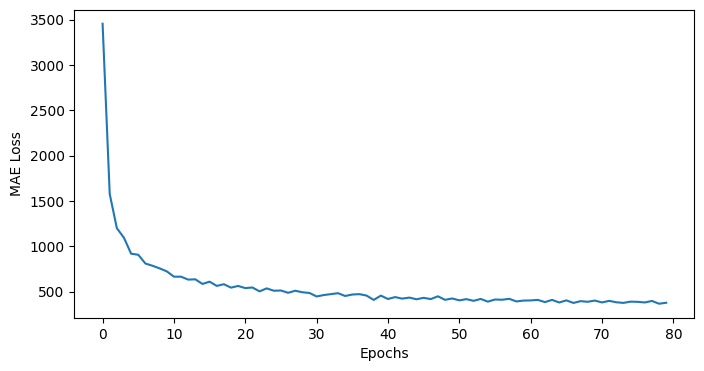

In [359]:
plt.figure(figsize=(8,4))
plt.plot(np.arange(len(losses[::10])),np.array(losses[::10]))
plt.xlabel('Epochs')
plt.ylabel('MAE Loss')

In [151]:
curr_batch = 0
passes = 0
myAEModel.eval()

re_test_loss = []
reconstructed_test_list = []
for batch in test_set:
    batch=batch.float().cuda()
    # batch = torch.nn.functional.normalize(batch,dim=1)
    # batch = (batch - torch.mean(batch,dim=1,keepdim=True))/torch.std(batch,dim=1,keepdim=True)
    batch = batch.permute((0,2,1))
    reconstructed = myAEModel(batch)
    
    r, _, _ = reconstructed.shape
    for i in range(r):
        loss = loss_function(reconstructed[i], batch[i])
        re_test_loss.append(loss.item())
        # print('test loss %d',loss.item())
    reconstructed_test_list.append(reconstructed.permute(0,2,1).float().cpu())
    
    
re_train_loss = []
reconstructed_train_list = []
for batch in train_set:
    batch=batch.float().cuda()
    # batch = torch.nn.functional.normalize(batch,dim=1)
    # batch = (batch - torch.mean(batch,dim=1,keepdim=True))/torch.std(batch,dim=1,keepdim=True)
    batch = batch.permute((0,2,1))
    reconstructed = myAEModel(batch)
    
    loss = loss_function(reconstructed, batch)
    
    r, _, _ = reconstructed.shape
    for i in range(r):
        loss = loss_function(reconstructed[i], batch[i])
        re_train_loss.append(loss.item())
        # print('test loss %d',loss.item())
    reconstructed_train_list.append(reconstructed.permute(0,2,1).float().cpu())
    
# print("re_train loss list::",re_train_loss)
# print("re_test loss list::",re_test_loss)

In [152]:
test_batch_num = 0
# 1 ~ batch_size 
test_exampel = 1

In [153]:
b, r,_ = reconstructed_test_list[test_batch_num].shape
re_test = reconstructed_test_list[test_batch_num].reshape(b*r,4)
test_l = []
for i in test_set:
    batch, row,_ = i.shape
    test_l.append(i.reshape(batch*50,4))
# b, r,_ = reconstructed_train_list[test_batch_num].shape
# re_train = reconstructed_train_list[test_batch_num].reshape(b*50,4)
# train_l = []
# for i in test_set:
#     batch, row,_ = i.shape
#     train_l.append(i.reshape(batch*50,4))

Text(0.5, 1.0, 'Speed')

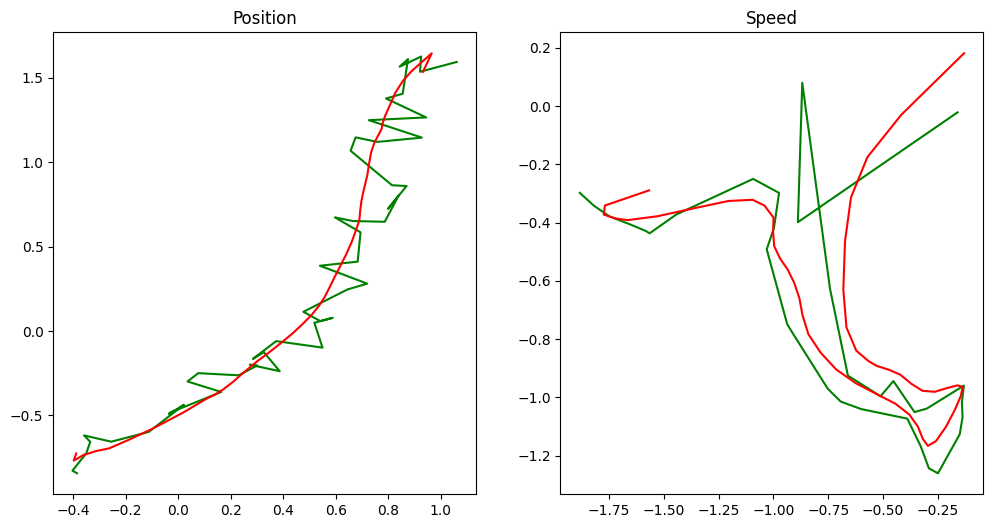

In [154]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,6))

p_start = (test_exampel-1)*50
p_stop = test_exampel*50

# s_start = (test_batch_num-1)*50+(test_exampel-1)*50
# s_stop = (test_batch_num-1)*50+test_exampel*50

x_plot = pd.DataFrame(test_l[test_batch_num])[p_start:p_stop][0]
y_plot = pd.DataFrame(test_l[test_batch_num])[p_start:p_stop][1]
# x_plot = (x_plot - x_plot.mean())/x_plot.std()
# y_plot = (y_plot - y_plot.mean())/y_plot.std()

x1_plot = pd.DataFrame(re_test.detach().numpy())[p_start:p_stop][0]
y1_plot = pd.DataFrame(re_test.detach().numpy())[p_start:p_stop][1]
ax1.plot(x_plot,y_plot,c='g',label='gt')
ax1.plot(x1_plot,y1_plot,c='r',label='pred')
ax1.set_title('Position')


x_plot = pd.DataFrame(test_l[test_batch_num])[p_start:p_stop][2]
y_plot = pd.DataFrame(test_l[test_batch_num])[p_start:p_stop][3]
# x_plot = (x_plot - x_plot.mean())/x_plot.std()
# y_plot = (y_plot - y_plot.mean())/y_plot.std()

x1_plot = pd.DataFrame(re_test.detach().numpy())[p_start:p_stop][2]
y1_plot = pd.DataFrame(re_test.detach().numpy())[p_start:p_stop][3]
ax2.plot(x_plot,y_plot,c='g',label='gt')
ax2.plot(x1_plot,y1_plot,c='r',label='pred')
ax2.set_title('Speed')

Text(0.5, 1.0, 'Speed Y')

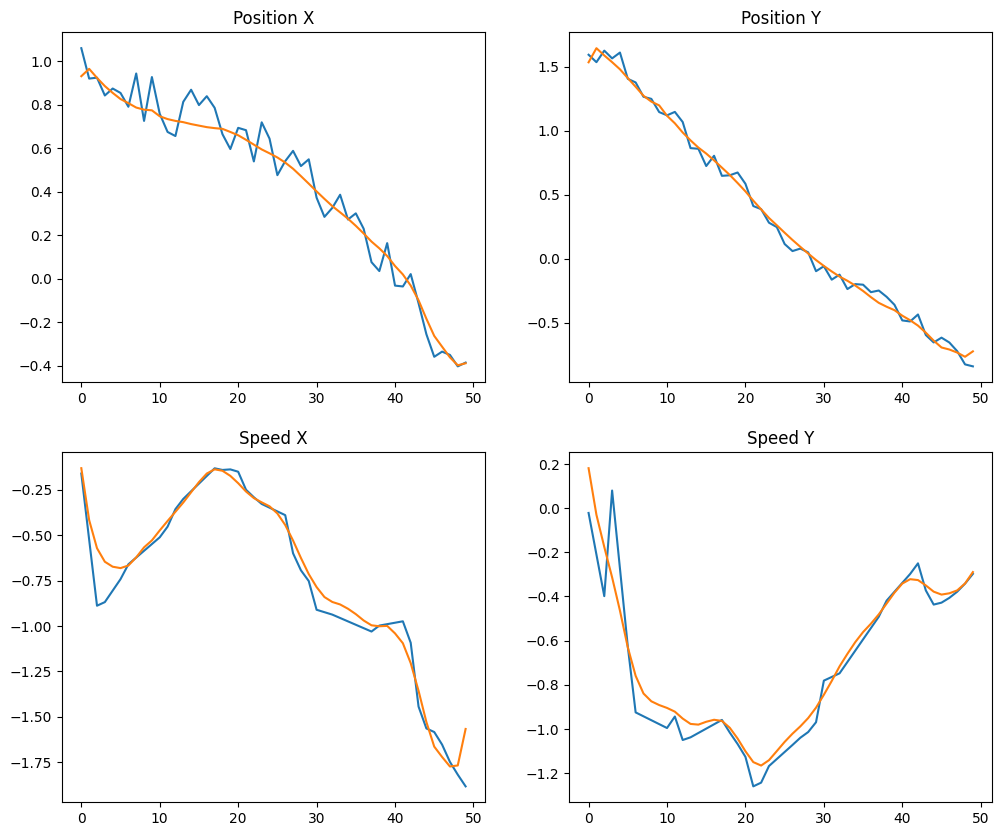

In [155]:
time_slot = np.arange(50)
plt.figure(figsize=(12,10))

x_plot = pd.DataFrame(test_l[test_batch_num])[p_start:p_stop][0]
y_plot = pd.DataFrame(test_l[test_batch_num])[p_start:p_stop][1]
# x_plot = (x_plot - x_plot.mean())/x_plot.std()
# y_plot = (y_plot - y_plot.mean())/y_plot.std()

x1_plot = pd.DataFrame(re_test.detach().numpy())[p_start:p_stop][0]
y1_plot = pd.DataFrame(re_test.detach().numpy())[p_start:p_stop][1]
ax = plt.subplot(221)
ax.plot(time_slot,x_plot)
ax.plot(time_slot,x1_plot)
ax.set_title('Position X')

ax = plt.subplot(222)
ax.plot(time_slot,y_plot)
ax.plot(time_slot,y1_plot)
ax.set_title('Position Y')


x_plot = pd.DataFrame(test_l[test_batch_num])[p_start:p_stop][2]
y_plot = pd.DataFrame(test_l[test_batch_num])[p_start:p_stop][3]
# x_plot = (x_plot - x_plot.mean())/x_plot.std()
# y_plot = (y_plot - y_plot.mean())/y_plot.std()

x1_plot = pd.DataFrame(re_test.detach().numpy())[p_start:p_stop][2]
y1_plot = pd.DataFrame(re_test.detach().numpy())[p_start:p_stop][3]
ax = plt.subplot(223)
ax.plot(time_slot,x_plot)
ax.plot(time_slot,x1_plot)
ax.set_title('Speed X')

ax = plt.subplot(224)
ax.plot(time_slot,y_plot)
ax.plot(time_slot,y1_plot)
ax.set_title('Speed Y')

threshold:: 0.46701735258102417
misbehavior:: (array([230]),)


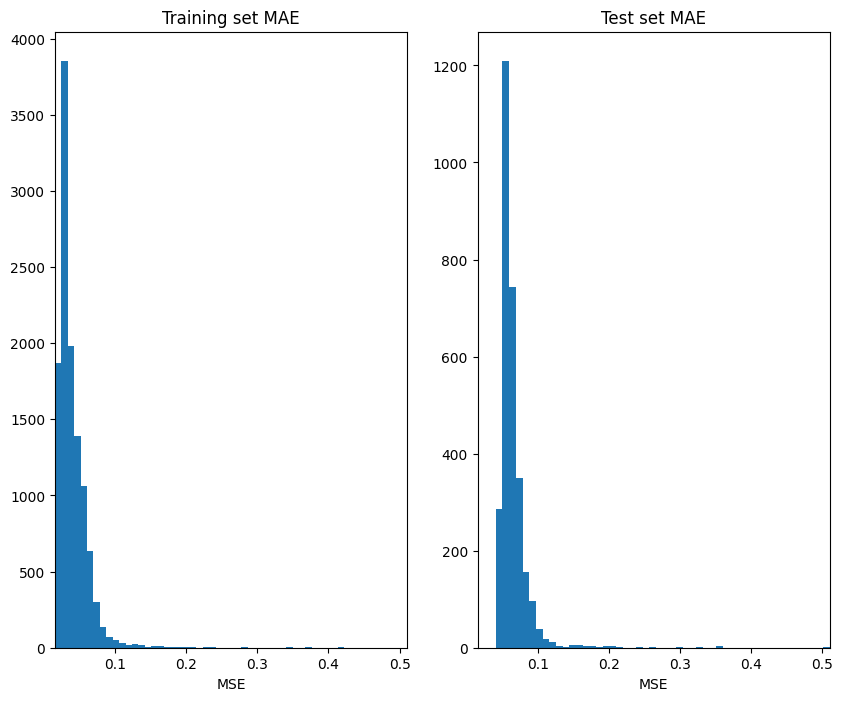

In [156]:
max_loss = max(max(re_train_loss),max(re_test_loss))
min_loss = min(min(re_train_loss),min(re_test_loss))

plt.figure(figsize=(10,8))

ax = plt.subplot(121)
x = np.array(re_train_loss)
ax.hist(x,bins=50)
ax.set_xlim(min_loss,max_loss)
ax.set_xlabel('MSE')
ax.set_title('Training set MAE')
threshold = max(re_train_loss)
print("threshold::",threshold)

ax = plt.subplot(122)
x = np.array(re_test_loss)
ax.hist(x,bins=50)
ax.set_xlim(min_loss,max_loss)
ax.set_xlabel('MSE')
ax.set_title('Test set MAE')
misbehavior = np.where(x>threshold)
print('misbehavior::',misbehavior)

## test VAE Model

In [157]:
model = ConvVAEModel()
print(model)

ConvVAEModel(
  (encoder): Sequential(
    (0): Conv1d(4, 64, kernel_size=(10,), stride=(1,))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.2, inplace=False)
    (3): Conv1d(64, 128, kernel_size=(10,), stride=(1,))
    (4): LeakyReLU(negative_slope=0.01)
    (5): Dropout(p=0.2, inplace=False)
    (6): ResNet(
      (module): Sequential(
        (0): Conv1d(128, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): LeakyReLU(negative_slope=0.01)
        (2): Conv1d(32, 128, kernel_size=(3,), stride=(1,), padding=(1,))
        (3): LeakyReLU(negative_slope=0.01)
      )
    )
    (7): ResNet(
      (module): Sequential(
        (0): Conv1d(128, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): LeakyReLU(negative_slope=0.01)
        (2): Conv1d(32, 128, kernel_size=(3,), stride=(1,), padding=(1,))
        (3): LeakyReLU(negative_slope=0.01)
      )
    )
    (8): Conv1d(128, 8, kernel_size=(10,), stride=(1,))
    (9): LeakyReLU(negative_slope=0.01)
  )
 

In [158]:
myVAEModel = ConvVAEModel()
# loss_function = nn.MSELoss(reduction='sum')
loss_function = nn.L1Loss(reduction='sum')
optimizer = optim.Adam(myVAEModel.parameters(), lr=1e-4, weight_decay=1e-8)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
myVAEModel.to(device)

outputs = []
losses = []

model_path = './dataset10/model/weights/'

total_num_batches = int(len(train_set))

for epoch in range(epochs):
    curr_batch = 0
    passes = 0
    for batch in train_set:
        batch=batch.float().cuda()
        # batch = torch.nn.functional.normalize(batch,dim=1)
        # batch = (batch - torch.mean(batch,dim=1,keepdim=True))/torch.std(batch,dim=1,keepdim=True)
        batch = batch.permute((0,2,1))
        reconstructed,_,_ = myVAEModel(batch)
        
        loss = loss_function(reconstructed, batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        if passes % 10 == 0:
            print("--- epoch %s | batch %s/%s --- [loss: %s]" %(epoch, curr_batch, total_num_batches, loss.item()))
            losses.append(loss.item())
            passes = 0

        passes += 1
        curr_batch += 1

    # save after every 10 epochs
    if epoch % 10 == 0:
        name = model_path + 'epoch_%s.pkl' % epoch
        print("====================")
        print ("Done with epoch %s!" % epoch)
        print ("Saving weights as %s ..." % name)
        # torch.save({
        #         'epoch': epoch,
        #         'model_state_dict': myModel.state_dict(),
        #         'optimizer_state_dict': optimizer.state_dict(),
        #         'loss': loss
        #         }, name)
        print("====================")


--- epoch 0 | batch 0/576 --- [loss: 3038.431640625]
--- epoch 0 | batch 10/576 --- [loss: 2673.47998046875]
--- epoch 0 | batch 20/576 --- [loss: 2364.9384765625]
--- epoch 0 | batch 30/576 --- [loss: 4379.85400390625]
--- epoch 0 | batch 40/576 --- [loss: 2725.1328125]
--- epoch 0 | batch 50/576 --- [loss: 2286.503662109375]
--- epoch 0 | batch 60/576 --- [loss: 2844.321533203125]
--- epoch 0 | batch 70/576 --- [loss: 2662.71142578125]
--- epoch 0 | batch 80/576 --- [loss: 2974.71337890625]
--- epoch 0 | batch 90/576 --- [loss: 2188.9267578125]
--- epoch 0 | batch 100/576 --- [loss: 1736.9593505859375]
--- epoch 0 | batch 110/576 --- [loss: 2356.65283203125]
--- epoch 0 | batch 120/576 --- [loss: 2281.50048828125]
--- epoch 0 | batch 130/576 --- [loss: 1962.99169921875]
--- epoch 0 | batch 140/576 --- [loss: 2566.533203125]
--- epoch 0 | batch 150/576 --- [loss: 2280.2109375]
--- epoch 0 | batch 160/576 --- [loss: 1364.7696533203125]
--- epoch 0 | batch 170/576 --- [loss: 2011.117675

KeyboardInterrupt: 

Text(0, 0.5, 'MAE Loss')

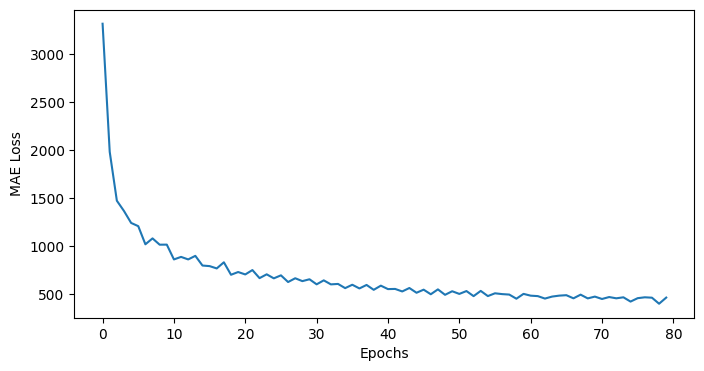

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(np.arange(len(losses[::10])),np.array(losses[::10]))
plt.xlabel('Epochs')
plt.ylabel('MAE Loss')

In [ ]:
curr_batch = 0
passes = 0
myVAEModel.eval()

re_test_loss = []
reconstructed_test_list = []
for batch in test_set:
    batch=batch.float().cuda()
    # batch = torch.nn.functional.normalize(batch,dim=1)
    # batch = (batch - torch.mean(batch,dim=1,keepdim=True))/torch.std(batch,dim=1,keepdim=True)
    batch = batch.permute((0,2,1))
    reconstructed,_,_ = myVAEModel(batch)
    
    r, _, _ = reconstructed.shape
    for i in range(r):
        loss = loss_function(reconstructed[i], batch[i])
        re_test_loss.append(loss.item())
        # print('test loss %d',loss.item())
    reconstructed_test_list.append(reconstructed.permute(0,2,1).float().cpu())
    
    
re_train_loss = []
reconstructed_train_list = []
for batch in train_set:
    batch=batch.float().cuda()
    # batch = torch.nn.functional.normalize(batch,dim=1)
    # batch = (batch - torch.mean(batch,dim=1,keepdim=True))/torch.std(batch,dim=1,keepdim=True)
    batch = batch.permute((0,2,1))
    reconstructed,_,_ = myVAEModel(batch)
    
    loss = loss_function(reconstructed, batch)
    
    r, _, _ = reconstructed.shape
    for i in range(r):
        loss = loss_function(reconstructed[i], batch[i])
        re_train_loss.append(loss.item())
        # print('test loss %d',loss.item())
    reconstructed_train_list.append(reconstructed.permute(0,2,1).float().cpu())
    
# print("re_train loss list::",re_train_loss)
# print("re_test loss list::",re_test_loss)

In [ ]:
test_batch_num = 10
# 1 ~ batch_size 
test_exampel =  1

b, r,_ = reconstructed_test_list[test_batch_num].shape
re_test = reconstructed_test_list[test_batch_num].reshape(b*50,4)
test_l = []
for i in test_set:
    batch, row,_ = i.shape
    test_l.append(i.reshape(batch*50,4))
    
# b, r,_ = reconstructed_train_list[test_batch_num].shape
# re_train = reconstructed_train_list[test_batch_num].reshape(b*50,4)
# train_l = []
# for i in test_set:
#     batch, row,_ = i.shape
#     train_l.append(i.reshape(batch*50,4))

Text(0.5, 1.0, 'Speed')

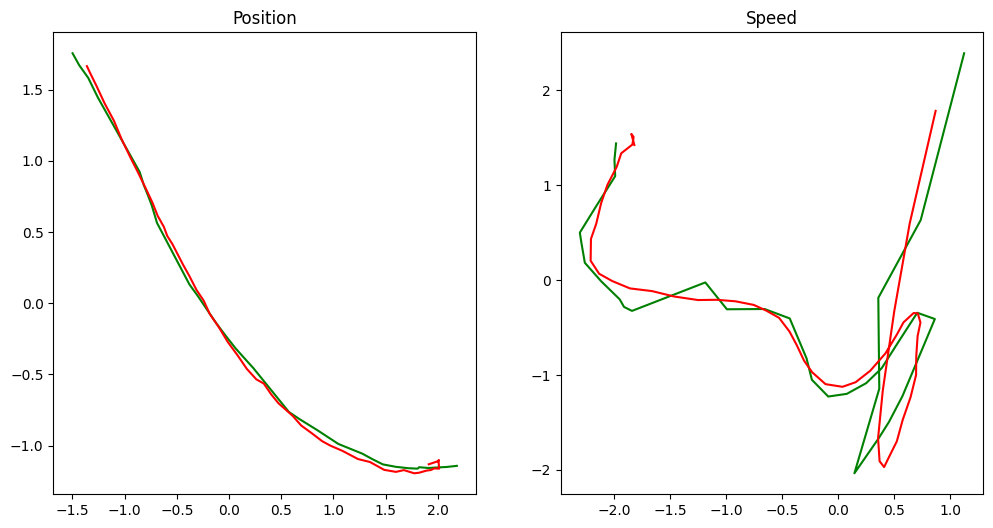

In [ ]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,6))

p_start = (test_exampel-1)*50
p_stop = test_exampel*50

s_start = test_batch_num*50+(test_exampel-1)*50
s_stop = test_batch_num*50+test_exampel*50

x_plot = pd.DataFrame(test_l[test_batch_num])[p_start:p_stop][0]
y_plot = pd.DataFrame(test_l[test_batch_num])[p_start:p_stop][1]
# x_plot = (x_plot - x_plot.mean())/x_plot.std()
# y_plot = (y_plot - y_plot.mean())/y_plot.std()

x1_plot = pd.DataFrame(re_test.detach().numpy())[p_start:p_stop][0]
y1_plot = pd.DataFrame(re_test.detach().numpy())[p_start:p_stop][1]
ax1.plot(x_plot,y_plot,c='g')
ax1.plot(x1_plot,y1_plot,c='r')
ax1.set_title('Position')


x_plot = pd.DataFrame(test_l[test_batch_num])[p_start:p_stop][2]
y_plot = pd.DataFrame(test_l[test_batch_num])[p_start:p_stop][3]
# x_plot = (x_plot - x_plot.mean())/x_plot.std()
# y_plot = (y_plot - y_plot.mean())/y_plot.std()

x1_plot = pd.DataFrame(re_test.detach().numpy())[p_start:p_stop][2]
y1_plot = pd.DataFrame(re_test.detach().numpy())[p_start:p_stop][3]
ax2.plot(x_plot,y_plot,c='g')
ax2.plot(x1_plot,y1_plot,c='r')
ax2.set_title('Speed')

Text(0.5, 1.0, 'Speed Y')

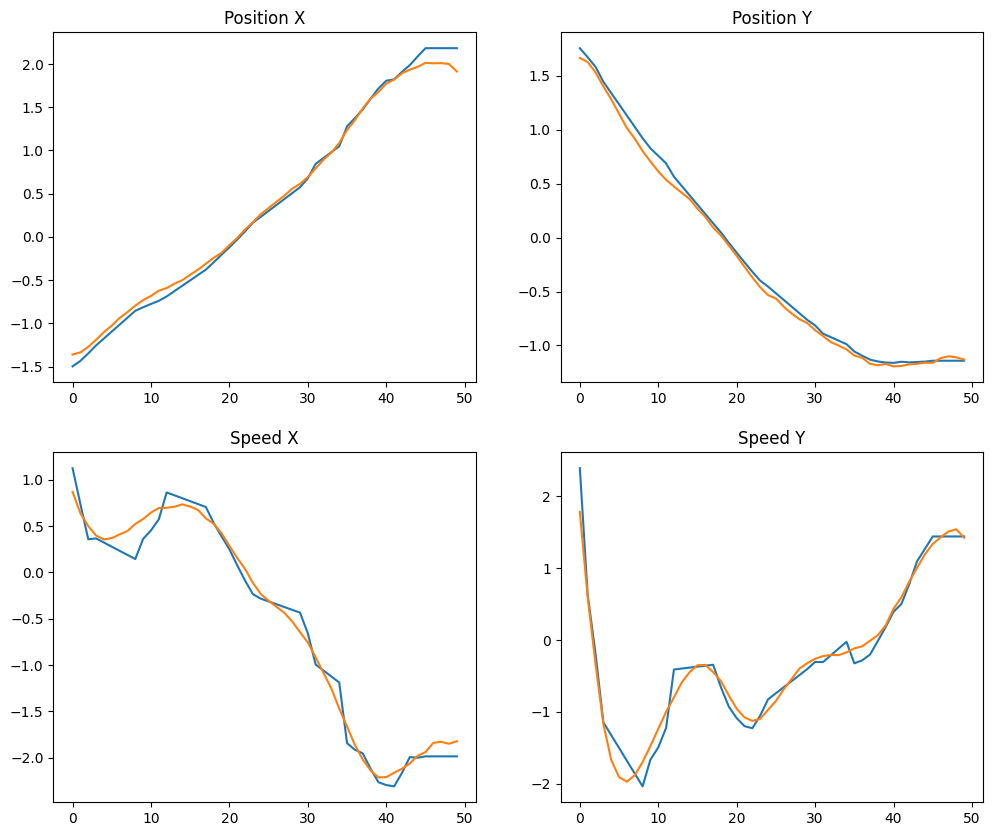

In [ ]:
time_slot = np.arange(50)
plt.figure(figsize=(12,10))

x_plot = pd.DataFrame(test_l[test_batch_num])[p_start:p_stop][0]
y_plot = pd.DataFrame(test_l[test_batch_num])[p_start:p_stop][1]
# x_plot = (x_plot - x_plot.mean())/x_plot.std()
# y_plot = (y_plot - y_plot.mean())/y_plot.std()

x1_plot = pd.DataFrame(re_test.detach().numpy())[p_start:p_stop][0]
y1_plot = pd.DataFrame(re_test.detach().numpy())[p_start:p_stop][1]
ax = plt.subplot(221)
ax.plot(time_slot,x_plot)
ax.plot(time_slot,x1_plot)
ax.set_title('Position X')

ax = plt.subplot(222)
ax.plot(time_slot,y_plot)
ax.plot(time_slot,y1_plot)
ax.set_title('Position Y')


x_plot = pd.DataFrame(test_l[test_batch_num])[p_start:p_stop][2]
y_plot = pd.DataFrame(test_l[test_batch_num])[p_start:p_stop][3]
# x_plot = (x_plot - x_plot.mean())/x_plot.std()
# y_plot = (y_plot - y_plot.mean())/y_plot.std()

x1_plot = pd.DataFrame(re_test.detach().numpy())[p_start:p_stop][2]
y1_plot = pd.DataFrame(re_test.detach().numpy())[p_start:p_stop][3]
ax = plt.subplot(223)
ax.plot(time_slot,x_plot)
ax.plot(time_slot,x1_plot)
ax.set_title('Speed X')

ax = plt.subplot(224)
ax.plot(time_slot,y_plot)
ax.plot(time_slot,y1_plot)
ax.set_title('Speed Y')

threshold:: 40.535255432128906
misbehavior:: (array([], dtype=int64),)


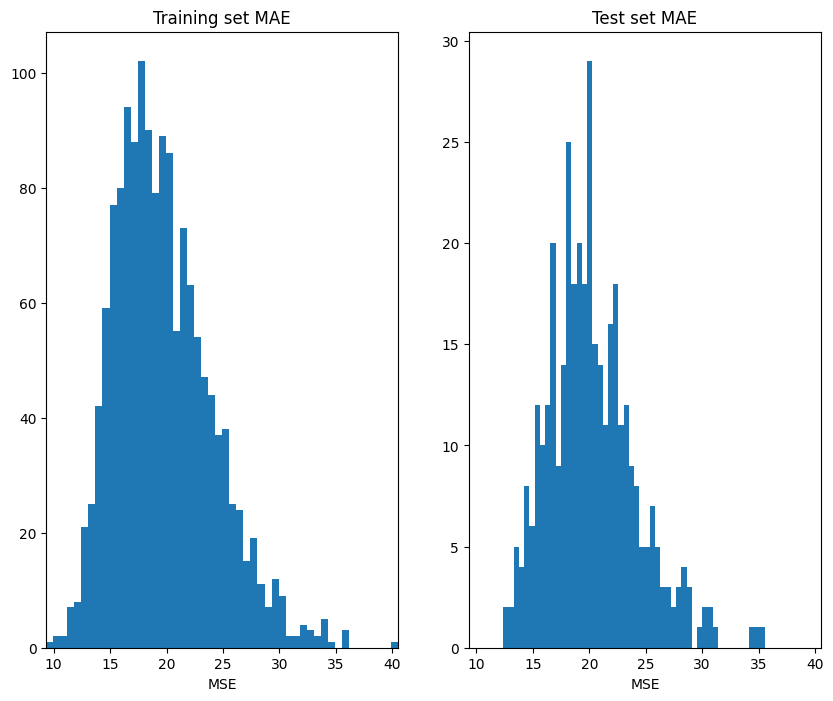

In [ ]:
max_loss = max(max(re_train_loss),max(re_test_loss))
min_loss = min(min(re_train_loss),min(re_test_loss))

plt.figure(figsize=(10,8))

ax = plt.subplot(121)
x = np.array(re_train_loss)
ax.hist(x,bins=50)
ax.set_xlim(min_loss,max_loss)
ax.set_xlabel('MSE')
ax.set_title('Training set MAE')
threshold = max(re_train_loss)
print("threshold::",threshold)

ax = plt.subplot(122)
x = np.array(re_test_loss)
ax.hist(x,bins=50)
ax.set_xlim(min_loss,max_loss)
ax.set_xlabel('MSE')
ax.set_title('Test set MAE')
misbehavior = np.where(x>threshold)
print('misbehavior::',misbehavior)

## test LSTM AE model

# Test with attack
## 1. training part

In [112]:
df_original = pd.read_csv('./dataset10/test/benign/20250711_11:53:11_benign.csv')
train_df = df_original.loc[:,['positionX','positionY','VelX','VelY']].copy()
row,col = train_df.shape
train_df = torch.tensor(train_df.values).view(int(row/50),50,col)
train_mean = torch.mean(train_df,dim=(0,1),keepdim=True)
train_std = torch.std(train_df,dim=(0,1),keepdim=True)
train_df = (train_df - train_mean)/train_std

In [113]:
epochs = 100
model_path = './dataset10/model/weights/'
splits = 5
kfold = KFold(n_splits=splits, shuffle=True)

outputs = []
losses = []

## Cross Validation
for fold, (train_ids, test_ids) in enumerate(kfold.split(train_df)):
    c_train_dataset = Subset(train_df, train_ids)
    train_batch_size = 20
    train_params = {'batch_size': train_batch_size,'shuffle':True}
    train_set = torch.utils.data.DataLoader(c_train_dataset, **train_params)
    total_num_batches = int(len(train_set))
    
    myModel = ConvVAEModel()
    # loss_function = nn.MSELoss(reduction='sum')
    loss_function = nn.L1Loss(reduction='mean')
    optimizer = optim.Adam(myModel.parameters(),lr=1e-4,weight_decay=1e-8)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    myModel.to(device)

    # Training for each epoch
    for epoch in range(1,epochs+1):
        curr_batch = 0
        passes = 0
        for batch in train_set:
            batch=batch.float().cuda()
            batch = batch.permute((0,2,1))
            reconstructed,_,_ = myModel(batch)
            
            loss = loss_function(reconstructed, batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


            if passes % 10 == 0:
                print("--- fold %s | epoch %s | batch %s/%s --- [loss: %s]" %(fold, epoch, curr_batch, total_num_batches, loss.item()))
                losses.append(loss.item())
                passes = 0

            passes += 1
            curr_batch += 1

        # save after every 50 epochs
        if epoch % 50 == 0:
            name = model_path + 'f_%s_epoch_%s_.pkl' % (fold, epoch)
            print("====================")
            print ("Cross Validation Fold %s!" % fold)
            print ("Done with epoch %s!" % epoch)
            print ("Saving weights as %s ..." % name)
            torch.save({
                    'fold': fold,
                    'epoch': epoch,
                    'model_state_dict': myModel.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': loss
                    }, name)
            print("====================")

--- fold 0 | epoch 1 | batch 0/578 --- [loss: 0.7375525236129761]
--- fold 0 | epoch 1 | batch 10/578 --- [loss: 0.7736154198646545]
--- fold 0 | epoch 1 | batch 20/578 --- [loss: 0.983015775680542]
--- fold 0 | epoch 1 | batch 30/578 --- [loss: 0.7665368318557739]
--- fold 0 | epoch 1 | batch 40/578 --- [loss: 0.9497979283332825]
--- fold 0 | epoch 1 | batch 50/578 --- [loss: 0.7454829216003418]
--- fold 0 | epoch 1 | batch 60/578 --- [loss: 0.558311939239502]
--- fold 0 | epoch 1 | batch 70/578 --- [loss: 0.6720954179763794]
--- fold 0 | epoch 1 | batch 80/578 --- [loss: 0.7443361878395081]
--- fold 0 | epoch 1 | batch 90/578 --- [loss: 0.484733909368515]
--- fold 0 | epoch 1 | batch 100/578 --- [loss: 0.6694590449333191]
--- fold 0 | epoch 1 | batch 110/578 --- [loss: 0.7399041652679443]
--- fold 0 | epoch 1 | batch 120/578 --- [loss: 0.6383106112480164]
--- fold 0 | epoch 1 | batch 130/578 --- [loss: 0.6619277596473694]
--- fold 0 | epoch 1 | batch 140/578 --- [loss: 0.434119343757

In [114]:
losses = np.array(losses).reshape(5,-1)

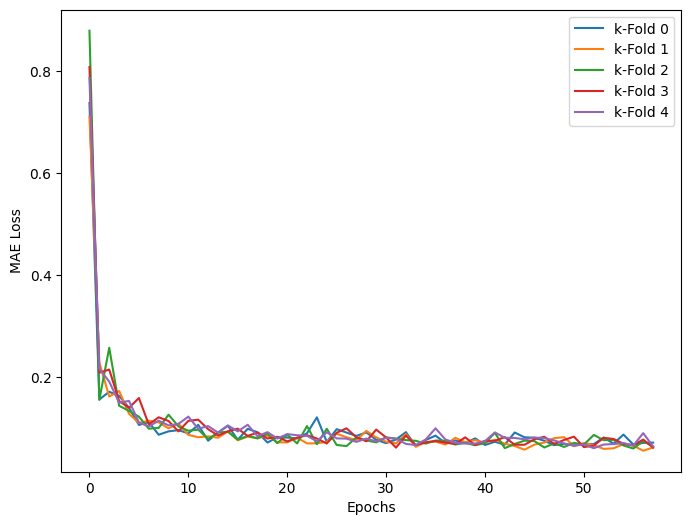

In [115]:
plt.figure(figsize=(8,6))
for i in range(5):
    plt.plot(np.arange(len(losses[i][::100])),np.array(losses[i][::100]),label='k-Fold %s' % i)
plt.xlabel('Epochs')
plt.ylabel('MAE Loss')
plt.legend()

## 2. validation part

In [155]:
df_original = pd.read_csv('./dataset10/test/benign/20250711_11:53:11_benign.csv')
train_df = df_original.loc[:,['positionX','positionY','VelX','VelY']].copy()
row,col = train_df.shape
train_df = torch.tensor(train_df.values).view(int(row/50),50,col)
train_mean = torch.mean(train_df,dim=(0,1),keepdim=True)
train_std = torch.std(train_df,dim=(0,1),keepdim=True)
train_df = (train_df - train_mean)/train_std

In [156]:
df = pd.read_csv('./dataset10/test/attacked/20250711_11:53:11_random_poistion_offset_pr0.2.csv')
df_benign = df[df['attacked'] == 0]
df_abnormal = df[df['attacked'] == 1]
ab_id = df_abnormal['Id'].unique()
df_compare = df_original[df_original['Id'].isin(ab_id)].copy()
df_compare.shape

(142550, 20)

In [157]:
# interval 3-6
df2 = pd.read_csv('./dataset10/test/attacked/20251011_11:22:28_random_poistion_offset_pr0.2.csv')
df2_abnormal = df2[df2['attacked'] == 1]
ab2_id = df2_abnormal['Id'].unique()
df2_compare = df_original[df_original['Id'].isin(ab2_id)].copy()
df2_compare.shape

# interval 6-9
df3 = pd.read_csv('./dataset10/test/attacked/20251011_16:14:17_random_poistion_offset_pr0.2.csv')
df3_abnormal = df3[df3['attacked'] == 1]
ab3_id = df3_abnormal['Id'].unique()
df3_compare = df_original[df_original['Id'].isin(ab3_id)].copy()
df3_compare.shape

(146150, 20)

In [158]:
df_compare.head(2), df_abnormal.head(2)

(         Id     timestamp  positionX  positionY  positionZ     sizeX  \
 900  2219.0  1.607508e+12  21.326345  48.893765  -4.959337  0.790101   
 901  2219.0  1.607508e+12  21.150524  48.626659  -4.903068  0.796389   
 
         sizeY     sizeZ      VelX      VelY      VelZ        Vel    Class  \
 900  0.160061  0.029845 -1.794895 -2.963203  0.610028  12.663792  UNKNOWN   
 901  0.159081  0.029757 -1.950035 -3.161972  0.654358  13.579630  UNKNOWN   
 
          rot_x      rot_y        edge   ts   departure destination  attacked  
 900 -45.021388  28.609227  60546306#0  0.0  60546306#0  60546290#0         0  
 901 -44.726262  28.486105  60546306#0  1.0  60546306#0  60546290#0         0  ,
          Id     timestamp  positionX  positionY  positionZ     sizeX  \
 900  2219.0  1.607508e+12  22.595091  48.525565  -4.959337  0.790101   
 901  2219.0  1.607508e+12  23.149580  48.316364  -4.903068  0.796389   
 
         sizeY     sizeZ      VelX      VelY      VelZ        Vel    Class  \
 90

In [159]:
test_df = df_abnormal.loc[:,['positionX','positionY','VelX','VelY']].copy()
row,col = test_df.shape
test_df = torch.tensor(test_df.values).view(int(row/50),50,col)
test_df = (test_df - train_mean)/train_std

test_df2 = df2_abnormal.loc[:,['positionX','positionY','VelX','VelY']].copy()
row,col = test_df2.shape
test_df2 = torch.tensor(test_df2.values).view(int(row/50),50,col)
test_df2 = (test_df2 - train_mean)/train_std

test_df3 = df3_abnormal.loc[:,['positionX','positionY','VelX','VelY']].copy()
row,col = test_df3.shape
test_df3 = torch.tensor(test_df3.values).view(int(row/50),50,col)
test_df3 = (test_df3 - train_mean)/train_std


comp_df = df_compare.loc[:,['positionX','positionY','VelX','VelY']].copy()
row,col = comp_df.shape
comp_df = torch.tensor(comp_df.values).view(int(row/50),50,col)
comp_df = (comp_df - train_mean)/train_std

comp_df2 = df2_compare.loc[:,['positionX','positionY','VelX','VelY']].copy()
row,col = comp_df2.shape
comp_df2 = torch.tensor(comp_df2.values).view(int(row/50),50,col)
comp_df2 = (comp_df2 - train_mean)/train_std

comp_df3 = df3_compare.loc[:,['positionX','positionY','VelX','VelY']].copy()
row,col = comp_df3.shape
comp_df3 = torch.tensor(comp_df3.values).view(int(row/50),50,col)
comp_df3 = (comp_df3 - train_mean)/train_std

train_batch_size = 1
train_params = {'batch_size': test_batch_size}
train_set = torch.utils.data.DataLoader(train_df, **train_params)

test_batch_size = 1
test_params = {'batch_size': test_batch_size}
test_set = torch.utils.data.DataLoader(test_df, **test_params)
test2_set = torch.utils.data.DataLoader(test_df2, **test_params)
test3_set = torch.utils.data.DataLoader(test_df3, **test_params)

test_df.shape

torch.Size([2851, 50, 4])

In [160]:
myModel = ConvVAEModel().cuda()
model_path = './dataset10/model/weights/'
loss_function = nn.L1Loss(reduction='mean')
# optimizer = optim.Adam(myAEModel.parameters(),lr=1e-4,weight_decay=1e-8)
model_lst = [x for x in sorted(os.listdir(model_path)) if x.endswith('.pkl')]
print(model_lst[-2])

f_4_epoch_100_.pkl


In [161]:
checkpoint = torch.load(model_path + '/%s'%model_lst[-2])
myModel.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']

myModel.eval()

re_test_loss = []
reconstructed_test_list = []
for batch in test_set:
    batch=batch.float().cuda()
    # batch = torch.nn.functional.normalize(batch,dim=1)
    # batch = (batch - torch.mean(batch,dim=1,keepdim=True))/torch.std(batch,dim=1,keepdim=True)
    batch = batch.permute((0,2,1))
    reconstructed,_,_ = myModel(batch)
    
    r, _, _ = reconstructed.shape
    for i in range(r):
        loss = loss_function(reconstructed[i], batch[i])
        re_test_loss.append(loss.item())
        # print('test loss %d',loss.item())
    reconstructed_test_list.append(reconstructed.permute(0,2,1).float().cpu())
    
re_test2_loss = []
reconstructed_test2_list = []
for batch in test2_set:
    batch=batch.float().cuda()
    batch = batch.permute((0,2,1))
    reconstructed,_,_ = myModel(batch)
    
    r, _, _ = reconstructed.shape
    for i in range(r):
        loss = loss_function(reconstructed[i], batch[i])
        re_test2_loss.append(loss.item())
    reconstructed_test2_list.append(reconstructed.permute(0,2,1).float().cpu())    
    
re_test3_loss = []
reconstructed_test3_list = []
for batch in test3_set:
    batch=batch.float().cuda()
    batch = batch.permute((0,2,1))
    reconstructed,_,_ = myModel(batch)
    
    r, _, _ = reconstructed.shape
    for i in range(r):
        loss = loss_function(reconstructed[i], batch[i])
        re_test3_loss.append(loss.item())
    reconstructed_test3_list.append(reconstructed.permute(0,2,1).float().cpu())    
    
re_train_loss = []
reconstructed_train_list = []
for batch in train_set:
    batch=batch.float().cuda()
    # batch = torch.nn.functional.normalize(batch,dim=1)
    # batch = (batch - torch.mean(batch,dim=1,keepdim=True))/torch.std(batch,dim=1,keepdim=True)
    batch = batch.permute((0,2,1))
    reconstructed,_,_ = myModel(batch)
    
    loss = loss_function(reconstructed, batch)
    
    r, _, _ = reconstructed.shape
    for i in range(r):
        loss = loss_function(reconstructed[i], batch[i])
        re_train_loss.append(loss.item())
        # print('test loss %d',loss.item())
    reconstructed_train_list.append(reconstructed.permute(0,2,1).float().cpu())

(0.0, 1.0)

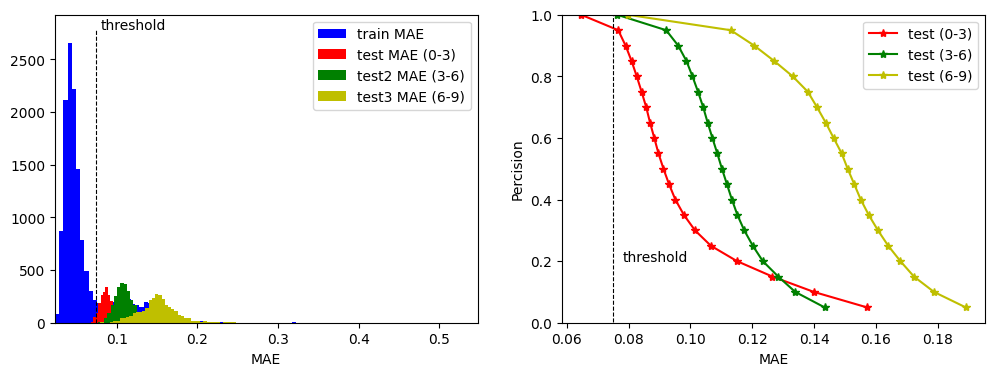

In [192]:
max_loss = max(max(re_train_loss),max(re_test_loss),max(re_test2_loss),max(re_test3_loss))
min_loss = min(min(re_train_loss),min(re_test_loss),min(re_test2_loss),min(re_test3_loss))

plt.figure(figsize=(12,4))

ax = plt.subplot(121)
x = np.array(re_train_loss)
ax.hist(x,bins=100,color='b',label='train MAE')

x1 = np.array(re_test_loss)
ax.hist(x1,bins=100,color='r',label='test MAE (0-3)')

x2 = np.array(re_test2_loss)
ax.hist(x2,bins=100,color='g',label='test2 MAE (3-6)')

x3 = np.array(re_test3_loss)
ax.hist(x3,bins=100,color='y',label='test3 MAE (6-9)')

ymin,ymax = ax.get_ylim()
ax.vlines(0.075,ymin,ymax,lw=0.8,ls='--',color='k')
ax.text(x=0.08,y=ymax,s='threshold')
ax.set_xlim(min_loss,max_loss)
ax.set_xlabel('MAE')
ax.legend()
# ax.set_title('Training set MAE')


# ax = plt.subplot(132)
# x = np.array(re_test_loss)
# ax.hist(x,bins=50)
# ax.set_xlim(min_loss,max_loss)
# ax.set_xlabel('MAE')
# ax.set_title('Test set MAE')


ax = plt.subplot(122)
precision_l = []
threshold_l = []
misbehavior_l = []
for i in range(20):
    threshold = np.sort(x1,axis=None)[int(len(x1)*(i*0.05))]
    misbehavior = np.where(x1>threshold)
    precision = misbehavior[0].shape[0]/len(x1)
    threshold_l.append(threshold) 
    precision_l.append(precision)
    misbehavior_l.append(misbehavior)
    # print('misbehavior shape %s' % misbehavior[0].shape)
    
precision_l2 = []
threshold_l2 = []
misbehavior_l2 = []
for i in range(20):
    threshold = np.sort(x2,axis=None)[int(len(x2)*(i*0.05))]
    misbehavior = np.where(x2>threshold)
    precision = misbehavior[0].shape[0]/len(x2)
    threshold_l2.append(threshold) 
    precision_l2.append(precision)
    misbehavior_l2.append(misbehavior)

precision_l3 = []
threshold_l3 = []
misbehavior_l3 = []
for i in range(20):
    threshold = np.sort(x3,axis=None)[int(len(x3)*(i*0.05))]
    misbehavior = np.where(x3>threshold)
    precision = misbehavior[0].shape[0]/len(x3)
    threshold_l3.append(threshold) 
    precision_l3.append(precision)
    misbehavior_l3.append(misbehavior)

ax.plot(threshold_l,precision_l,'*-',color='r',label='test (0-3)')
ax.plot(threshold_l2,precision_l2,'*-',color='g',label='test (3-6)')
ax.plot(threshold_l3,precision_l3,'*-',color='y',label='test (6-9)')
ax.set_xlabel('MAE')
ax.set_ylabel('Percision')
ymin,ymax = ax.get_ylim()
ax.vlines(0.075,ymin,ymax,lw=0.8,ls='--',color='k')
ax.text(x=0.078,y=0.2,s='threshold')
ax.legend()
ax.set_ylim(0,1)

In [163]:
# 1 ~ batch_size 
test_exampel =  1
r,_,_ = test_df.shape
re_test_l = []
num = np.random.randint(r,size=4)
for i in range(4):
    b, r,_ = reconstructed_test_list[num[i]].shape
    re_test = reconstructed_test_list[num[i]].reshape(b*50,4)
    re_test_l.append(re_test)
    
    
r,_,_ = test_df2.shape
re_test2_l = []
num2 = np.random.randint(r,size=4)
for i in range(4):
    b, r,_ = reconstructed_test2_list[num2[i]].shape
    re_test2 = reconstructed_test2_list[num2[i]].reshape(b*50,4)
    re_test2_l.append(re_test2)
    
    
r,_,_ = test_df3.shape
re_test3_l = []
num3 = np.random.randint(r,size=4)
for i in range(4):
    b, r,_ = reconstructed_test3_list[num3[i]].shape
    re_test3 = reconstructed_test3_list[num3[i]].reshape(b*50,4)
    re_test3_l.append(re_test3)

#579337 loss:: 0.08388067036867142 
#579337 is abnormal
#301432 loss:: 0.08129392564296722 
#301432 is abnormal
#135387 loss:: 0.07889635115861893 
#135387 is normal
#149471 loss:: 0.08811336010694504 
#149471 is abnormal


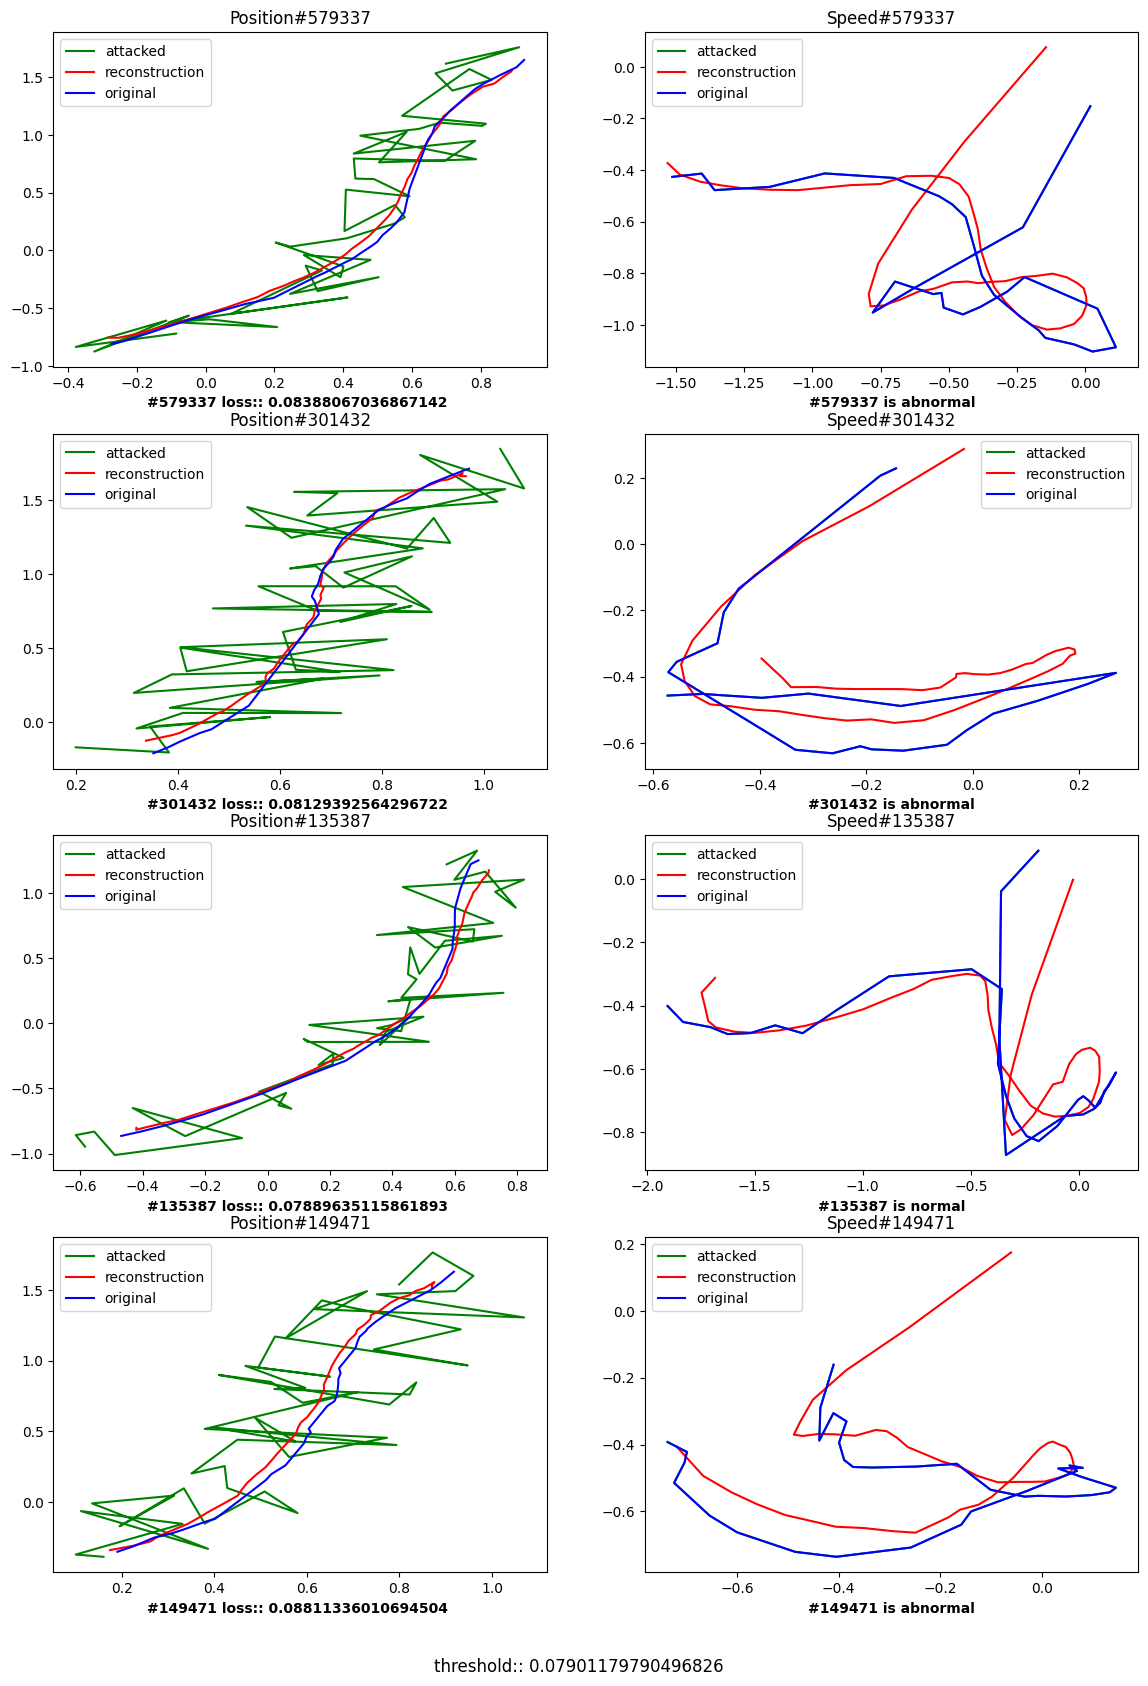

In [181]:
plt.figure(figsize=(14,20))
interval = 2
txt='threshold:: %s' % threshold_l[interval]
plt.figtext(0.5, 0.06, txt, wrap=True, horizontalalignment='center', fontsize=12)
for i in range(8):
    idx = 421+i
    ax = plt.subplot(idx)
    if i%2 == 0:
        x_plot = pd.DataFrame(test_df.view((-1,4)).detach().numpy()).iloc[num[i//2]*50:(num[i//2]+1)*50][0]
        y_plot = pd.DataFrame(test_df.view((-1,4)).detach().numpy()).iloc[num[i//2]*50:(num[i//2]+1)*50][1]
        
        x1_plot = pd.DataFrame(re_test_l[i//2].detach().numpy())[:][0]
        y1_plot = pd.DataFrame(re_test_l[i//2].detach().numpy())[:][1]
        
        x2_plot = pd.DataFrame(comp_df.reshape((-1,4)).detach().numpy()).iloc[num[i//2]*50:(num[i//2]+1)*50][0]
        y2_plot = pd.DataFrame(comp_df.reshape((-1,4)).detach().numpy()).iloc[num[i//2]*50:(num[i//2]+1)*50][1]
        
        ax.set_title('Position'+'#'+str(int(df_abnormal.iloc[num[i//2]*50,0])))
        
        p_loss = '#%s loss:: %s ' % (int(df_abnormal.iloc[num[i//2]*50,0]), re_test_loss[num[i//2]])
        print(p_loss)
        ax.set_xlabel(p_loss,fontweight='bold')
    
    else:
        x_plot = pd.DataFrame(test_df.view((-1,4)).detach().numpy()).iloc[num[i//2]*50:(num[i//2]+1)*50][2]
        y_plot = pd.DataFrame(test_df.view((-1,4)).detach().numpy()).iloc[num[i//2]*50:(num[i//2]+1)*50][3]
        
        x1_plot = pd.DataFrame(re_test_l[i//2].detach().numpy())[:][2]
        y1_plot = pd.DataFrame(re_test_l[i//2].detach().numpy())[:][3]
        
        x2_plot = pd.DataFrame(comp_df.reshape((-1,4)).detach().numpy()).iloc[num[i//2]*50:(num[i//2]+1)*50][2]
        y2_plot = pd.DataFrame(comp_df.reshape((-1,4)).detach().numpy()).iloc[num[i//2]*50:(num[i//2]+1)*50][3]        
        ax.set_title('Speed'+'#'+str(int(df_abnormal.iloc[num[i//2]*50,0])))
        
        p_ab=f'#{int(df_abnormal.iloc[num[i//2]*50,0])} is normal'
        if num[i//2] in misbehavior_l[interval][0]:
            p_ab = f'#{int(df_abnormal.iloc[num[i//2]*50,0])} is abnormal'
        print(p_ab)
        ax.set_xlabel(p_ab,fontweight='bold')
        
    ax.plot(x_plot,y_plot,c='g',label='attacked')
    ax.plot(x1_plot,y1_plot,c='r',label='reconstruction')
    ax.plot(x2_plot,y2_plot,c='b',label='original')
    ax.legend()

#7408617 loss:: 0.10873246192932129 
#7408617 is abnormal
#294452 loss:: 0.11100360006093979 
#294452 is abnormal
#731550 loss:: 0.12700805068016052 
#731550 is abnormal
#503751 loss:: 0.09733857214450836 
#503751 is abnormal


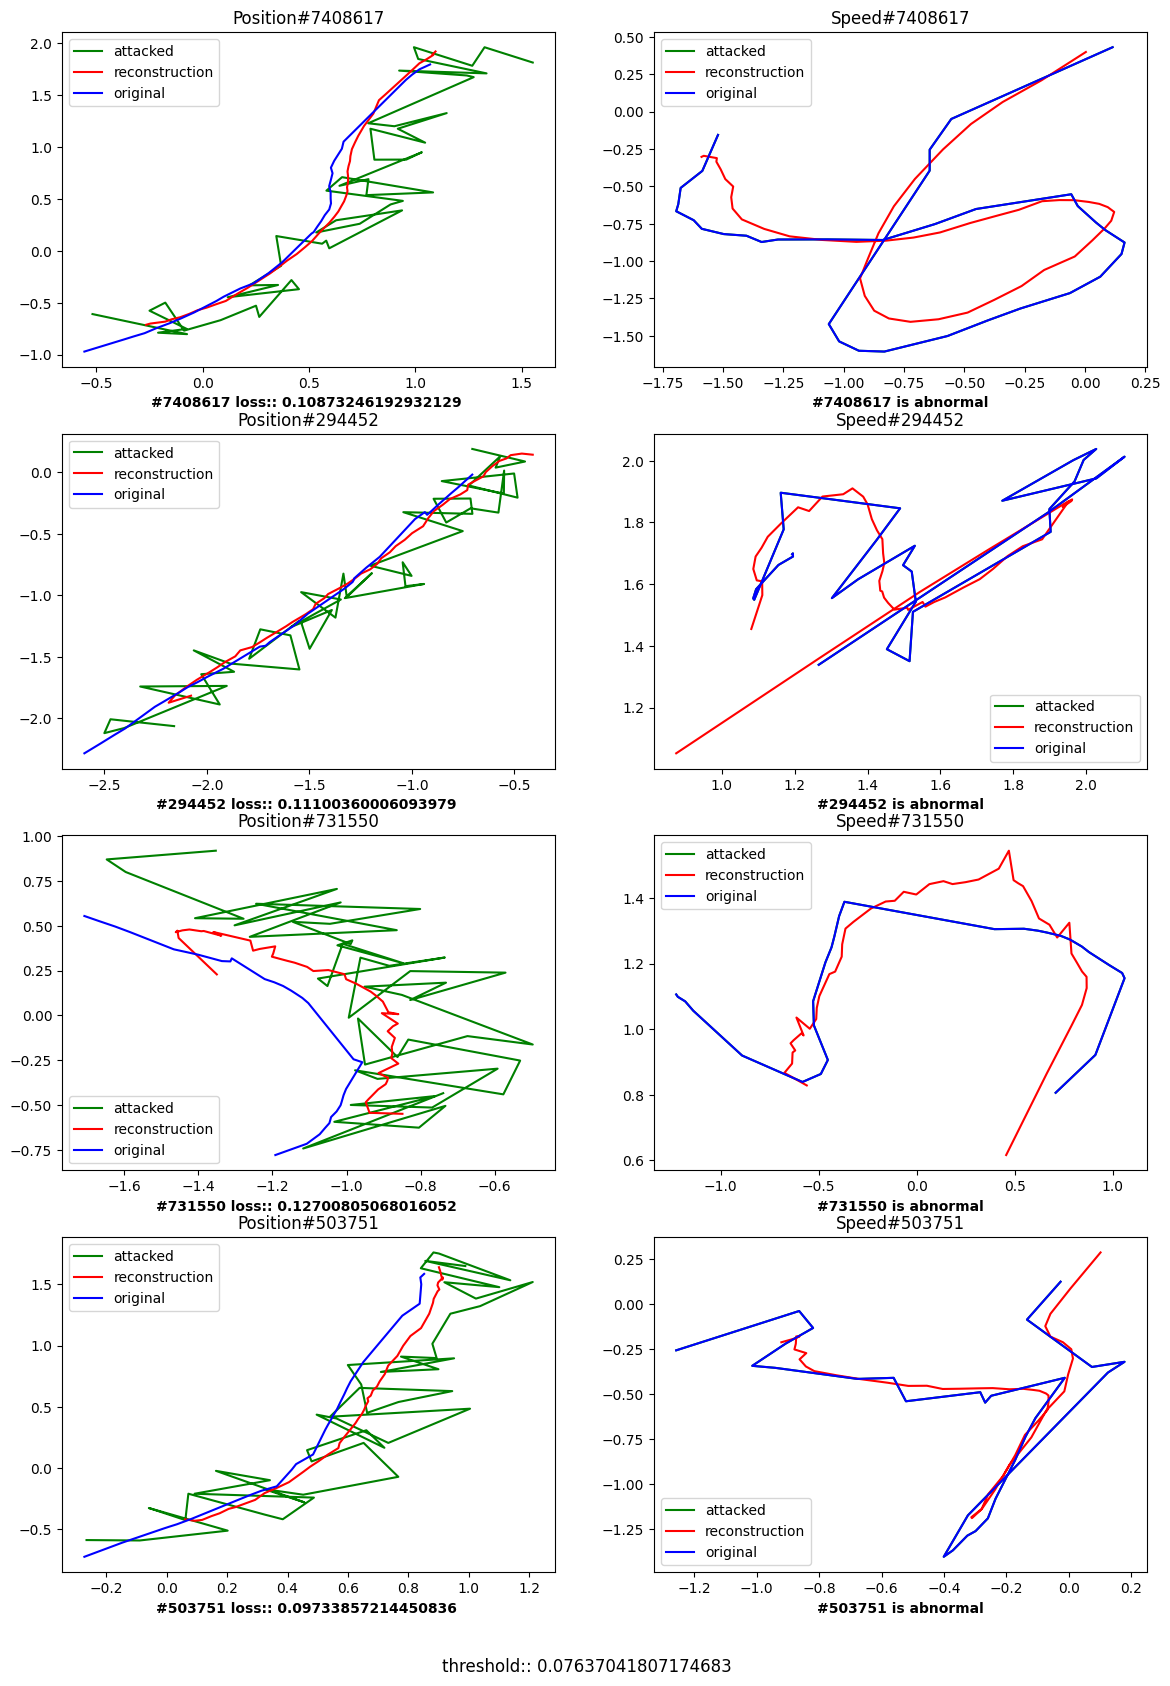

In [182]:
plt.figure(figsize=(14,20))
interval = 0
txt='threshold:: %s' % threshold_l2[interval]
plt.figtext(0.5, 0.06, txt, wrap=True, horizontalalignment='center', fontsize=12)
for i in range(8):
    idx = 421+i
    ax = plt.subplot(idx)
    if i%2 == 0:
        x_plot = pd.DataFrame(test_df2.view((-1,4)).detach().numpy()).iloc[num2[i//2]*50:(num2[i//2]+1)*50][0]
        y_plot = pd.DataFrame(test_df2.view((-1,4)).detach().numpy()).iloc[num2[i//2]*50:(num2[i//2]+1)*50][1]
        
        x1_plot = pd.DataFrame(re_test2_l[i//2].detach().numpy())[:][0]
        y1_plot = pd.DataFrame(re_test2_l[i//2].detach().numpy())[:][1]
        
        x2_plot = pd.DataFrame(comp_df2.reshape((-1,4)).detach().numpy()).iloc[num2[i//2]*50:(num2[i//2]+1)*50][0]
        y2_plot = pd.DataFrame(comp_df2.reshape((-1,4)).detach().numpy()).iloc[num2[i//2]*50:(num2[i//2]+1)*50][1]
        
        ax.set_title('Position'+'#'+str(int(df2_abnormal.iloc[num2[i//2]*50,0])))
        
        p_loss = '#%s loss:: %s ' % (int(df2_abnormal.iloc[num2[i//2]*50,0]), re_test2_loss[num2[i//2]])
        print(p_loss)
        ax.set_xlabel(p_loss,fontweight='bold')
    
    else:
        x_plot = pd.DataFrame(test_df2.view((-1,4)).detach().numpy()).iloc[num2[i//2]*50:(num2[i//2]+1)*50][2]
        y_plot = pd.DataFrame(test_df2.view((-1,4)).detach().numpy()).iloc[num2[i//2]*50:(num2[i//2]+1)*50][3]
        
        x1_plot = pd.DataFrame(re_test2_l[i//2].detach().numpy())[:][2]
        y1_plot = pd.DataFrame(re_test2_l[i//2].detach().numpy())[:][3]
        
        x2_plot = pd.DataFrame(comp_df2.reshape((-1,4)).detach().numpy()).iloc[num2[i//2]*50:(num2[i//2]+1)*50][2]
        y2_plot = pd.DataFrame(comp_df2.reshape((-1,4)).detach().numpy()).iloc[num2[i//2]*50:(num2[i//2]+1)*50][3]        
        ax.set_title('Speed'+'#'+str(int(df2_abnormal.iloc[num2[i//2]*50,0])))
        
        p_ab=f'#{int(df2_abnormal.iloc[num2[i//2]*50,0])} is normal'
        if num2[i//2] in misbehavior_l2[interval][0]:
            p_ab = f'#{int(df2_abnormal.iloc[num2[i//2]*50,0])} is abnormal'
        print(p_ab)
        ax.set_xlabel(p_ab,fontweight='bold')
        
    ax.plot(x_plot,y_plot,c='g',label='attacked')
    ax.plot(x1_plot,y1_plot,c='r',label='reconstruction')
    ax.plot(x2_plot,y2_plot,c='b',label='original')
    ax.legend()

#889342 loss:: 0.14763569831848145 
#889342 is abnormal
#375862 loss:: 0.13068553805351257 
#375862 is abnormal
#1222817 loss:: 0.17513306438922882 
#1222817 is abnormal
#7293435 loss:: 0.13909976184368134 
#7293435 is abnormal


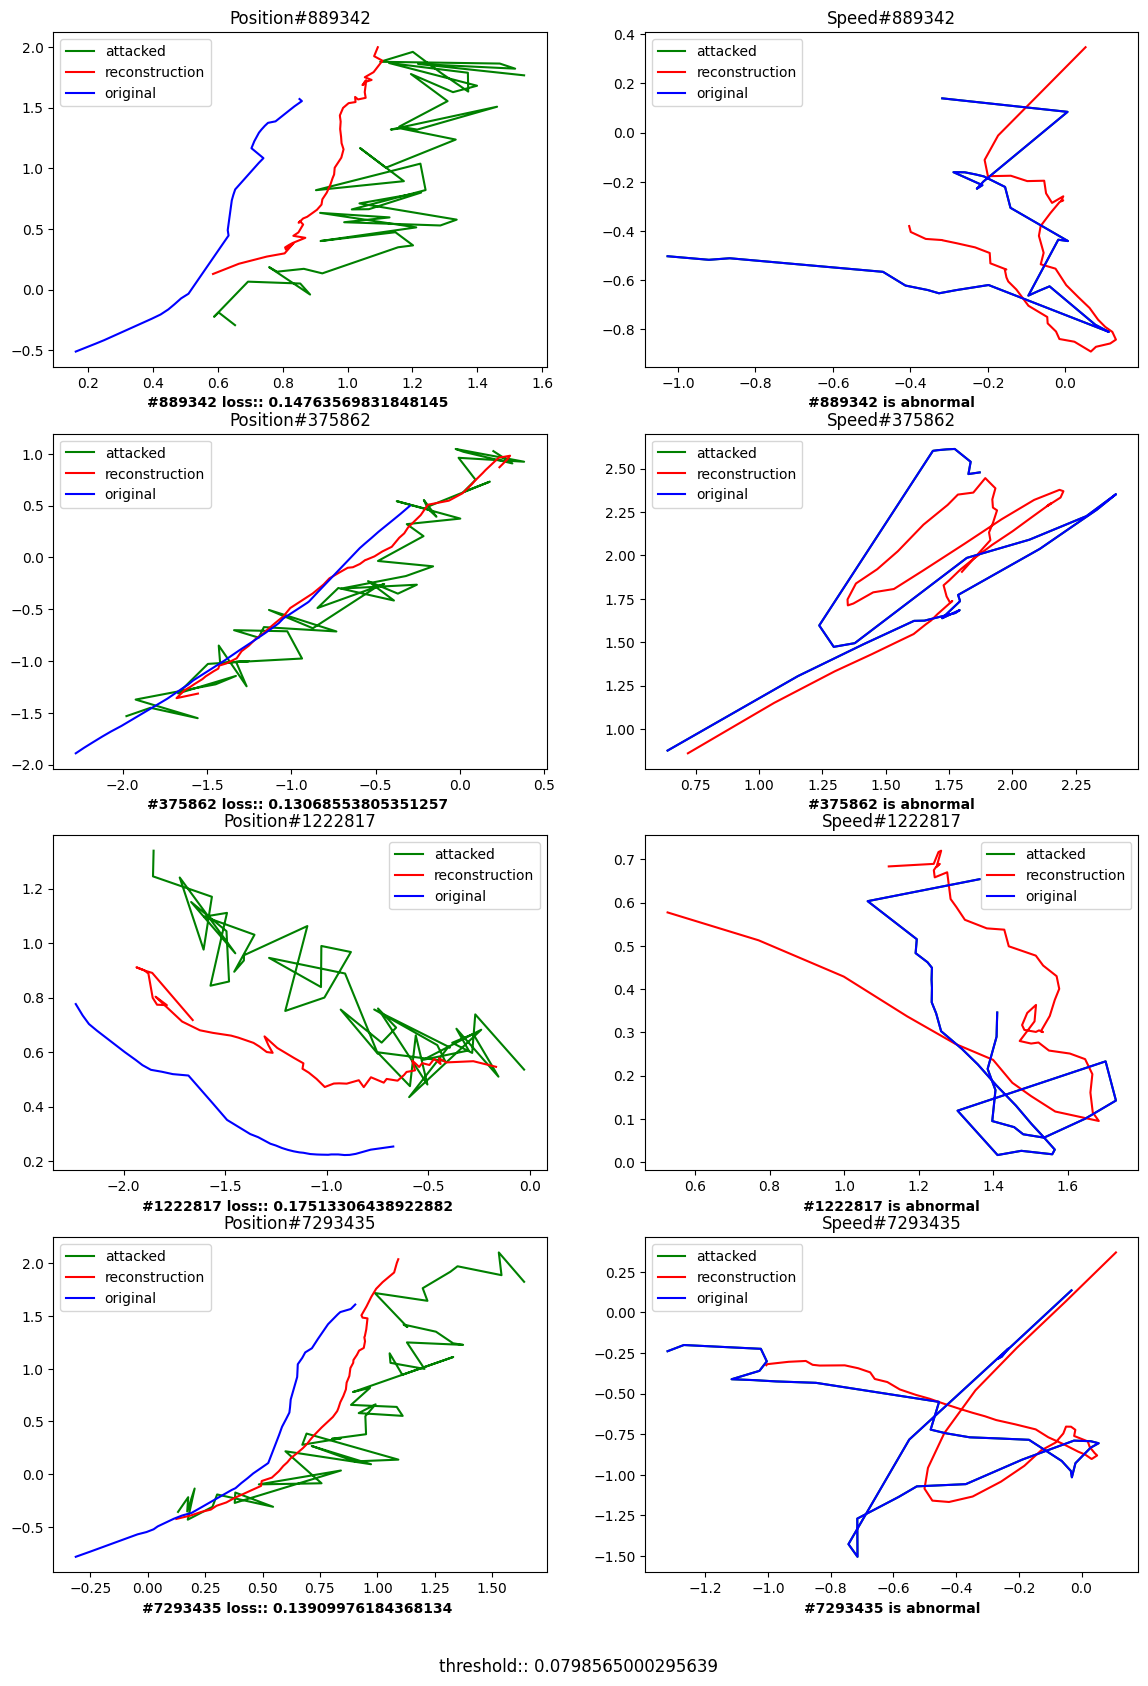

In [183]:
plt.figure(figsize=(14,20))
interval = 0
txt='threshold:: %s' % threshold_l3[interval]
plt.figtext(0.5, 0.06, txt, wrap=True, horizontalalignment='center', fontsize=12)
for i in range(8):
    idx = 421+i
    ax = plt.subplot(idx)
    if i%2 == 0:
        x_plot = pd.DataFrame(test_df3.view((-1,4)).detach().numpy()).iloc[num3[i//2]*50:(num3[i//2]+1)*50][0]
        y_plot = pd.DataFrame(test_df3.view((-1,4)).detach().numpy()).iloc[num3[i//2]*50:(num3[i//2]+1)*50][1]
        
        x1_plot = pd.DataFrame(re_test3_l[i//2].detach().numpy())[:][0]
        y1_plot = pd.DataFrame(re_test3_l[i//2].detach().numpy())[:][1]
        
        x2_plot = pd.DataFrame(comp_df3.reshape((-1,4)).detach().numpy()).iloc[num3[i//2]*50:(num3[i//2]+1)*50][0]
        y2_plot = pd.DataFrame(comp_df3.reshape((-1,4)).detach().numpy()).iloc[num3[i//2]*50:(num3[i//2]+1)*50][1]
        
        ax.set_title('Position'+'#'+str(int(df3_abnormal.iloc[num3[i//2]*50,0])))
        
        p_loss = '#%s loss:: %s ' % (int(df3_abnormal.iloc[num3[i//2]*50,0]), re_test3_loss[num3[i//2]])
        print(p_loss)
        ax.set_xlabel(p_loss,fontweight='bold')
    
    else:
        x_plot = pd.DataFrame(test_df3.view((-1,4)).detach().numpy()).iloc[num3[i//2]*50:(num3[i//2]+1)*50][2]
        y_plot = pd.DataFrame(test_df3.view((-1,4)).detach().numpy()).iloc[num3[i//2]*50:(num3[i//2]+1)*50][3]
        
        x1_plot = pd.DataFrame(re_test3_l[i//2].detach().numpy())[:][2]
        y1_plot = pd.DataFrame(re_test3_l[i//2].detach().numpy())[:][3]
        
        x2_plot = pd.DataFrame(comp_df3.reshape((-1,4)).detach().numpy()).iloc[num3[i//2]*50:(num3[i//2]+1)*50][2]
        y2_plot = pd.DataFrame(comp_df3.reshape((-1,4)).detach().numpy()).iloc[num3[i//2]*50:(num3[i//2]+1)*50][3]        
        ax.set_title('Speed'+'#'+str(int(df3_abnormal.iloc[num3[i//2]*50,0])))
        
        p_ab=f'#{int(df3_abnormal.iloc[num3[i//2]*50,0])} is normal'
        if num3[i//2] in misbehavior_l3[interval][0]:
            p_ab = f'#{int(df3_abnormal.iloc[num3[i//2]*50,0])} is abnormal'
        print(p_ab)
        ax.set_xlabel(p_ab,fontweight='bold')
        
    ax.plot(x_plot,y_plot,c='g',label='attacked')
    ax.plot(x1_plot,y1_plot,c='r',label='reconstruction')
    ax.plot(x2_plot,y2_plot,c='b',label='original')
    ax.legend()